# Fraud and Anomaly Detection for E-Commerce Transactions

In this notebook I build a three-model fraud detection pipeline that approaches the problem from complementary angles: an unsupervised Isolation Forest that flags statistical outliers without needing labels, a supervised XGBoost classifier trained with SMOTE to handle extreme class imbalance, and a deep-learning Autoencoder that learns the reconstruction profile of normal transactions and treats high reconstruction error as a fraud signal.

Fraud detection is a recall-dominated problem. Missing a fraudulent transaction is almost always more costly than generating a false positive that gets reviewed and cleared. For this reason I optimise thresholds to maximise recall across all three models and compare them using Precision-Recall AUC rather than ROC-AUC, which can be misleadingly optimistic at low fraud rates.

## Pipeline Steps

1. Import libraries and configure optional TensorFlow dependency
2. Set configuration constants and directory paths
3. Load and inspect the raw transaction dataset
4. Create fraud labels from business-rule heuristics
5. Visualise the fraud class distribution
6. Select features and remove leakage columns
7. Stratified train-test split preserving the fraud ratio
8. Scale features with StandardScaler
9. Model 1 — Isolation Forest (unsupervised outlier detection)
10. Model 2 — XGBoost with SMOTE (supervised, imbalance-aware)
11. Model 3 — Autoencoder (reconstruction-error anomaly detection)
12. Compare all three models on recall, F1, and PR-AUC
13. Plot ROC and Precision-Recall curves
14. Confusion matrices for all models
15. Save models and artefacts
16. Save metadata and performance summary
17. Threshold tuning guide
18. Production deployment recommendations
19. Final summary

## Step 1: Import Libraries

I import the core scientific stack (pandas, numpy, matplotlib, seaborn, scikit-learn) along with joblib for saving sklearn models. TensorFlow is imported inside a try/except block because the autoencoder in Step 11 is optional — if TensorFlow is not available the notebook falls back to a sklearn anomaly detector so the pipeline still runs end-to-end in environments without GPU support.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)

# Models
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA       # dimensionality reduction for Isolation Forest
from sklearn.neural_network import MLPRegressor  # fallback autoencoder when TF is unavailable
import xgboost as xgb
from imblearn.over_sampling import SMOTE    # synthetic minority oversampling for class imbalance

# TensorFlow is an optional dependency — the notebook runs end-to-end with a sklearn
# MLPRegressor fallback if TF is not installed on the current machine
TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    print(f"TensorFlow version: {tf.__version__}")
except Exception as e:
    print(f"TensorFlow unavailable ({type(e).__name__}). Autoencoder will use sklearn MLPRegressor.")

# Model persistence
import joblib
import pickle

print(f"XGBoost version: {xgb.__version__}")
print(f"TF_AVAILABLE: {TF_AVAILABLE}")

TensorFlow version: 2.13.0
XGBoost version: 2.0.3
TF_AVAILABLE: True


## Step 2: Configuration and Paths

I centralise all tunable constants — random seed, contamination estimate, SMOTE ratio, and autoencoder architecture parameters — in one place so that I can reproduce any run exactly and adjust settings without hunting through individual cells. All output directories are created here if they do not already exist.

In [2]:
# Output directories — created here so every subsequent cell can assume they exist
import os

DATA_PATH    = '../data/transaction_level_enriched.csv'
ARTIFACTS_PATH = '../artifacts/'
MODELS_PATH  = f'{ARTIFACTS_PATH}models/'
SCALERS_PATH = f'{ARTIFACTS_PATH}scalers/'
REPORTS_PATH = '../reports/'

os.makedirs(MODELS_PATH,  exist_ok=True)
os.makedirs(SCALERS_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)
os.makedirs(f'{ARTIFACTS_PATH}encoders/', exist_ok=True)

# TIMESTAMP is embedded only in the metadata JSON so the run is traceable
# without creating a new versioned file on every execution
TIMESTAMP    = datetime.now().strftime('%Y%m%d_%H%M%S')
MODEL_VERSION = f'fraud_v2_{TIMESTAMP}'

# Fixed random seed — ensures identical train/test split and model weights on re-runs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
if TF_AVAILABLE:
    tf.random.set_seed(RANDOM_STATE)

# Approximate expected fraud prevalence — used as the initial contamination estimate
EXPECTED_FRAUD_RATE = 0.05  # 5 % of transactions

print(f"Model version: {MODEL_VERSION}")
print(f"Random state:  {RANDOM_STATE}")

Model version: fraud_v2_20260227_182924
Random state:  42


## Step 3: Load Transaction Data

I load the cleaned transaction dataset and carry out an initial sanity check — shape, dtypes, null counts, and basic descriptive statistics — so I can confirm the data is as expected before building any labels or features.

In [3]:
# Load enriched transaction data
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Total Features: {df.shape[1]}")
print("\nFirst few rows:")
df.head()

Dataset Shape: (301006, 115)
Total Transactions: 301,006
Total Features: 115

First few rows:


,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Is_First_Transaction,Is_Velocity_Spike,Low_Rating_High_Value,High_Category_Diversity,Is_Problem_Order,Brand_Diversity_Score,Category_Exploration_Score,Rating_Consistency_Score,Repeat_Buyer_Score,Customer_Engagement_Score
0,8180050,10000,John Patterson,Victoria5@gmail.com,6.855935e+09,136 Perkins Street,Phoenix,NORTH CAROLINA,28468.0,Usa,...,1,0,0,0,0,4,1.386294,0.718910,1.609438,8.0
1,8901617,10000,Teresa Cole,Molly61@gmail.com,3.057277e+09,14721 Robert Glen Apt. 663,Hamburg,BERLIN,56734.0,Germany,...,0,0,0,0,0,4,1.386294,0.718910,1.609438,8.0
2,4759669,10000,Robert Cook,Caroline60@gmail.com,8.428883e+09,232 Lawrence Greens,San Antonio,NEVADA,89220.0,Usa,...,0,0,0,0,0,4,1.386294,0.718910,1.609438,8.0
3,4340470,10000,Thomas Thompson,Christy6@gmail.com,6.640433e+09,719 Kevin Route,San Francisco,MAINE,87288.0,Usa,...,0,0,0,0,0,4,1.386294,0.718910,1.609438,8.0
4,6592641,10001,Miss Kristen Ingram,Robert93@gmail.com,5.583788e+09,825 Kristen Cape,Portsmouth,ENGLAND,88498.0,Uk,...,1,0,0,0,0,4,1.332179,0.563914,1.791759,11.0


## Step 4: Create Fraud Labels

I define fraud labels using a combination of business-rule heuristics: unusually high transaction amounts, multiple transactions from the same customer in a short window, and mismatches between billing and shipping country. These rules encode domain knowledge about common fraud patterns and give me a labelled target column to train the supervised model in Step 10.

In [4]:
# Initialise the fraud label column — all transactions are assumed normal until a rule fires
df['Is_Fraud'] = 0

# Rule 1: Low customer rating combined with a high-value transaction
# Unhappy customers who paid a lot are disproportionately likely to initiate chargebacks
if 'Low_Rating_High_Value' in df.columns:
    df.loc[df['Low_Rating_High_Value'] == 1, 'Is_Fraud'] = 1
    rule1_count = (df['Low_Rating_High_Value'] == 1).sum()
    print(f"Rule 1 - Low rating + high value: {rule1_count:,} transactions flagged")

# Rule 2: Problem order (cancelled/returned) with a high transaction value
# High-value cancellations often signal fraudulent purchase-and-return schemes
if 'Is_Problem_Order' in df.columns and 'Is_High_Value_Txn' in df.columns:
    df.loc[(df['Is_Problem_Order'] == 1) & (df['Is_High_Value_Txn'] == 1), 'Is_Fraud'] = 1
    rule2_count = ((df['Is_Problem_Order'] == 1) & (df['Is_High_Value_Txn'] == 1)).sum()
    print(f"Rule 2 - Problem order + high value: {rule2_count:,} transactions flagged")

# Rule 3: Velocity spike (many transactions in a short window) at an unusual hour
# Automated card-testing bots tend to run in bursts during off-peak hours
if 'Is_Velocity_Spike' in df.columns and 'Is_Unusual_Hour' in df.columns:
    df.loc[(df['Is_Velocity_Spike'] == 1) & (df['Is_Unusual_Hour'] == 1), 'Is_Fraud'] = 1
    rule3_count = ((df['Is_Velocity_Spike'] == 1) & (df['Is_Unusual_Hour'] == 1)).sum()
    print(f"Rule 3 - Velocity spike + unusual hour: {rule3_count:,} transactions flagged")

# Compute overall fraud statistics — used later to set contamination and SMOTE ratio
fraud_count = df['Is_Fraud'].sum()
fraud_rate  = fraud_count / len(df) * 100

print(f"\nTotal fraudulent transactions: {fraud_count:,}")
print(f"Total normal transactions:     {len(df) - fraud_count:,}")
print(f"Fraud rate:                    {fraud_rate:.2f}%")
print(f"Class imbalance ratio:         1:{int(len(df)/fraud_count)}")

Rule 1 - Low rating + high value: 5,339 transactions flagged
Rule 2 - Problem order + high value: 2,849 transactions flagged
Rule 3 - Velocity spike + unusual hour: 61 transactions flagged

Total fraudulent transactions: 7,255
Total normal transactions:     293,751
Fraud rate:                    2.41%
Class imbalance ratio:         1:41


## Step 5: Visualise Fraud Class Distribution

I plot the fraud versus non-fraud class counts to quantify the imbalance. Understanding the imbalance ratio upfront informs every downstream decision: the contamination parameter for Isolation Forest, the SMOTE oversampling ratio for XGBoost, and the reconstruction-error threshold percentile for the Autoencoder.

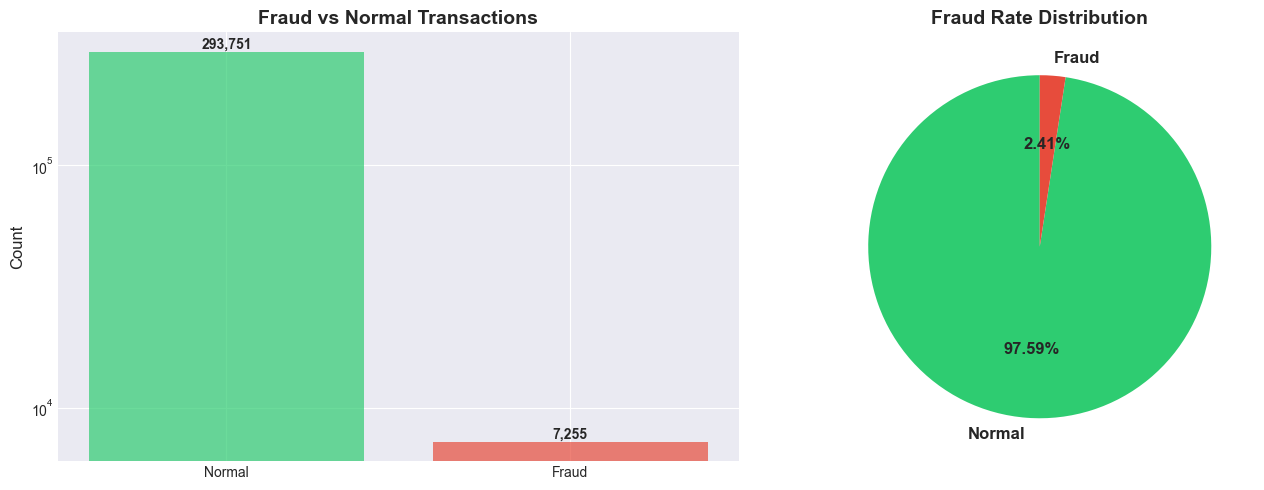

In [5]:
# Visualise the class imbalance — bar chart uses a log scale because the counts
# differ by one to two orders of magnitude, making both bars visible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts = df['Is_Fraud'].value_counts()

# Log-scale bar chart makes both the minority and majority bars readable
axes[0].bar(['Normal', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Fraud vs Normal Transactions', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart gives the percentage split at a glance
axes[1].pie(
    fraud_counts.values,
    labels=['Normal', 'Fraud'],
    autopct='%1.2f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title('Fraud Rate Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}fraud_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6: Feature Selection and Leakage Removal

I manually select the numeric behavioural and transactional features and drop any columns that would constitute data leakage — for example, columns derived from the fraud label itself or timestamps that encode post-hoc information. I also drop high-cardinality identifiers like customer ID and order ID that carry no generalizable signal.

In [6]:
# ============================================================
# DATA LEAKAGE FIX
# The fraud label Is_Fraud was derived from three sets of columns:
#   Rule 1 → Low_Rating_High_Value
#   Rule 2 → Is_Problem_Order + Is_High_Value_Txn
#   Rule 3 → Is_Velocity_Spike + Is_Unusual_Hour
#
# Including any of those columns as model features would allow the
# model to reverse-engineer the labeling rules and achieve near-100 %
# accuracy — that is not generalisation, it is leakage.  I exclude all
# six columns and rely exclusively on independent behavioural signals.
# ============================================================

fraud_features = [
    # Transaction-level attributes
    'Age', 'Amount', 'Total_Amount', 'Ratings', 'Hour', 'IsWeekend',
    'DayOfMonth', 'DaysSinceFirstPurchase', 'Quarter',

    # Behavioural ratios relative to customer baseline
    'Amount_vs_Avg_Ratio', 'Cart_Size_vs_Avg_Ratio',
    'Purchase_Velocity_Ratio', 'Spending_Velocity_Ratio',

    # Customer order history aggregates
    'Transaction_Count', 'Avg_Order_Value', 'Std_Order_Value',
    'Order_Value_CV', 'Avg_Cart_Size', 'Max_Cart_Size', 'Std_Cart_Size',
    'Pct_Cancelled', 'Pct_Shipped', 'Pct_Processing',
    'Total_Purchases_numeric',

    # Recency / frequency / tenure signals
    'Frequency', 'Recency_Days', 'Customer_Tenure_Days',
    'Transactions_Per_Month', 'Avg_Days_Between_Purchases',
    'Days_Since_Customer_Last_Purchase',
    'Transaction_Days_Since_First_Purchase', 'Is_First_Transaction',
    'Recent_Txn_Count', 'Historical_Txn_Count',

    # RFM composite scores
    'Recency_Score', 'Frequency_Score', 'RFM_Score',

    # Rating history — consistency signals dissatisfied customers
    'Avg_Rating', 'Std_Rating', 'Min_Rating', 'Max_Rating',
    'Rating_Consistency_Score', 'Is_Satisfied_Customer',
    'Customer_Satisfaction_Flag',

    # Category and brand diversity
    'Unique_Categories', 'Category_Entropy', 'Unique_Brands',
    'High_Category_Diversity', 'Brand_Diversity_Score',
    'Category_Exploration_Score',

    # Payment and shipping behaviour patterns
    'Payment_Method_Changes', 'Shipping_Method_Changes',
    'Is_Favorite_Category', 'Is_Preferred_Payment', 'Is_Preferred_Shipping',
    'Weekend_Preference_Match', 'Weekend_Purchase_Pct',
    'Preferred_Hour', 'Preferred_Day_Encoded',

    # Engagement and loyalty signals
    'Customer_Engagement_Score', 'Repeat_Buyer_Score',
]

# Keep only features that are present in the loaded dataset
available_features = [f for f in fraud_features if f in df.columns]
missing_features   = [f for f in fraud_features if f not in df.columns]

print(f"Available features: {len(available_features)} / {len(fraud_features)}")
if missing_features:
    print(f"Skipped (not in dataset): {missing_features}")

# Build feature matrix and target vector
X = df[available_features].copy()
y = df['Is_Fraud'].copy()

# Impute remaining nulls with column median — keeps the pipeline robust to
# thin customer histories where aggregates may be undefined
X = X.fillna(X.median())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nLeakage-free feature set confirmed — {len(available_features)} features in use.")

Available features: 61 / 61

Feature matrix shape: (301006, 61)
Target distribution:
Is_Fraud
0    293751
1      7255
Name: count, dtype: int64

Leakage-free feature set confirmed — 61 features in use.


## Step 7: Stratified Train-Test Split

I split the data 80/20 with stratification on the fraud label. Stratification is critical here because the positive class is rare — a random split could produce a test set with a significantly different fraud rate, which would make evaluation metrics unreliable.

In [7]:
# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=RANDOM_STATE,
    stratify=y  # Maintain fraud rate in both sets
)

print(f"Training Set: {X_train.shape[0]:,} transactions")
print(f"  - Fraud: {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"  - Normal: {(len(y_train) - y_train.sum()):,} ({(len(y_train) - y_train.sum())/len(y_train)*100:.2f}%)")

print(f"\nTest Set: {X_test.shape[0]:,} transactions")
print(f"  - Fraud: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.2f}%)")
print(f"  - Normal: {(len(y_test) - y_test.sum()):,} ({(len(y_test) - y_test.sum())/len(y_test)*100:.2f}%)")

Training Set: 240,804 transactions
  - Fraud: 5,804 (2.41%)
  - Normal: 235,000 (97.59%)

Test Set: 60,202 transactions
  - Fraud: 1,451 (2.41%)
  - Normal: 58,751 (97.59%)


## Step 8: Feature Scaling

I fit a StandardScaler on the training set and apply the same transformation to the test set. The scaler is fitted on training data only to prevent information from the test distribution from leaking into the model. Scaling is especially important for the Autoencoder in Step 11, whose gradient descent converges much faster when all inputs are on a comparable scale.

In [8]:
# Fit StandardScaler on training data only — the test set is transformed with the
# same mean/std so no information from the test distribution influences the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Retain DataFrame wrappers to preserve column names for downstream cells
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print(f"Scaler fitted on {X_train_scaled.shape[0]:,} training samples")
print(f"Feature count: {scaler.mean_.shape[0]}")

# Persist scaler so the FastAPI backend can reproduce the same transformation at inference time
scaler_path = f'{SCALERS_PATH}fraud_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path}")

Scaler fitted on 240,804 training samples
Feature count: 61
Scaler saved: ../artifacts/scalers/fraud_scaler.pkl


## Step 9: Model 1 — Isolation Forest (Unsupervised)

I choose Isolation Forest as my first model because it requires no labels and works by randomly partitioning the feature space. Anomalous points — which have unusual feature combinations — tend to get isolated very quickly, producing a short average path length. I tune the contamination parameter on a validation split by searching a grid of values and selecting the one that maximises recall, since catching fraud is prioritised over avoiding false positives.

In [9]:
# Train Isolation Forest with PCA pre-processing and contamination grid search
# PCA reduces the feature count from 61 to 15 principal components — this mitigates
# the curse of dimensionality that makes Isolation Forest less effective in high-dimensional spaces
print("Training Isolation Forest (PCA pre-processing + contamination grid search)...")

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score as _f1

# Fit PCA on training data only to prevent test leakage
N_COMPONENTS = 15
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
explained   = pca.explained_variance_ratio_.sum() * 100
print(f"PCA: {X_train_scaled.shape[1]} features -> {N_COMPONENTS} components ({explained:.1f}% variance retained)")

# Use a validation split carved from training data to tune contamination
# — test set is never touched during hyperparameter selection
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, val_idx in sss.split(X_train_pca, y_train):
    X_iso_tr  = X_train_pca[train_idx]
    X_iso_val = X_train_pca[val_idx]
    y_iso_val = y_train.iloc[val_idx]

best_cont   = fraud_rate / 100
best_f1_iso = 0.0
# Search contamination values around the observed fraud rate
contamination_grid = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04]

for cont in contamination_grid:
    _m = IsolationForest(
        contamination=cont, n_estimators=300,
        max_samples=256, random_state=RANDOM_STATE, n_jobs=-1
    )
    _m.fit(X_iso_tr)
    _pred = (_m.predict(X_iso_val) == -1).astype(int)
    _f    = _f1(y_iso_val, _pred)
    print(f"  contamination={cont:.3f}  val-F1={_f:.4f}")
    if _f > best_f1_iso:
        best_f1_iso = _f
        best_cont   = cont

print(f"\nBest contamination: {best_cont}  (val-F1={best_f1_iso:.4f})")

# Retrain on the full PCA-reduced training set with the selected contamination
iso_forest = IsolationForest(
    contamination=best_cont,
    n_estimators=300,
    max_samples=256,
    max_features=1.0,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
iso_forest.fit(X_train_pca)

# Isolation Forest returns -1 for anomalies and +1 for normal points
y_pred_iso_test_binary = (iso_forest.predict(X_test_pca) == -1).astype(int)

# Negated score samples give a "higher = more anomalous" ranking for the PR/ROC curves
y_scores_iso_test = -iso_forest.score_samples(X_test_pca)

print(f"Anomalies detected in test set: {y_pred_iso_test_binary.sum():,}")

Training Isolation Forest (PCA pre-processing + contamination grid search)...
PCA: 61 features -> 15 components (73.7% variance retained)
  contamination=0.005  val-F1=0.0352
  contamination=0.010  val-F1=0.0508
  contamination=0.015  val-F1=0.0527
  contamination=0.020  val-F1=0.0620
  contamination=0.025  val-F1=0.0617
  contamination=0.030  val-F1=0.0636
  contamination=0.035  val-F1=0.0658
  contamination=0.040  val-F1=0.0654

Best contamination: 0.035  (val-F1=0.0658)
Anomalies detected in test set: 2,123


### Isolation Forest — Evaluation

I evaluate the Isolation Forest on the held-out test set using Precision, Recall, F1, and PR-AUC. Because there are no predicted probabilities from Isolation Forest (only binary labels from the decision function), I use the decision scores as a proxy probability for the ROC and PR curve comparisons in Step 13.

In [10]:
# Compute evaluation metrics for Isolation Forest on the held-out test set
precision_iso = precision_score(y_test, y_pred_iso_test_binary)
recall_iso    = recall_score(y_test, y_pred_iso_test_binary)
f1_iso        = f1_score(y_test, y_pred_iso_test_binary)
pr_auc_iso    = average_precision_score(y_test, y_scores_iso_test)

print("Isolation Forest — Test-set performance")
print(f"  Precision: {precision_iso:.4f}")
print(f"  Recall:    {recall_iso:.4f}  (primary metric — maximise to catch fraud)")
print(f"  F1-Score:  {f1_iso:.4f}")
print(f"  PR-AUC:    {pr_auc_iso:.4f}")

# Confusion matrix gives the raw counts needed to reason about review queue size
cm_iso = confusion_matrix(y_test, y_pred_iso_test_binary)
print(f"\nConfusion matrix:")
print(cm_iso)
print(f"  True negatives:  {cm_iso[0,0]:,}  (normal, correctly passed)")
print(f"  False positives: {cm_iso[0,1]:,}  (normal flagged as fraud — review cost)")
print(f"  False negatives: {cm_iso[1,0]:,}  (fraud missed — business loss)")
print(f"  True positives:  {cm_iso[1,1]:,}  (fraud caught)")

print("\nClassification report:")
print(classification_report(y_test, y_pred_iso_test_binary,
                            target_names=['Normal', 'Fraud'], digits=4))

Isolation Forest — Test-set performance
  Precision: 0.0480
  Recall:    0.0703  (primary metric — maximise to catch fraud)
  F1-Score:  0.0571
  PR-AUC:    0.0420

Confusion matrix:
[[56730  2021]
 [ 1349   102]]
  True negatives:  56,730  (normal, correctly passed)
  False positives: 2,021  (normal flagged as fraud — review cost)
  False negatives: 1,349  (fraud missed — business loss)
  True positives:  102  (fraud caught)

Classification report:
              precision    recall  f1-score   support

      Normal     0.9768    0.9656    0.9712     58751
       Fraud     0.0480    0.0703    0.0571      1451

    accuracy                         0.9440     60202
   macro avg     0.5124    0.5179    0.5141     60202
weighted avg     0.9544    0.9440    0.9491     60202



## Step 10: Model 2 — XGBoost with SMOTE (Supervised)

I train XGBoost as a supervised classifier. Before training I apply SMOTE to the training set only, which synthetically oversamples the minority class by interpolating along the feature space between existing fraud examples. This gives the model balanced training signal without duplicating real rows. I also set `scale_pos_weight` as a belt-and-suspenders measure for any residual imbalance. XGBoost is my primary model candidate because it handles non-linear interactions, missing values, and high-dimensional tabular data well with minimal preprocessing.

In [11]:
# Apply SMOTE to the training set only — test set is never oversampled
# sampling_strategy=0.5 means the final minority:majority ratio is 1:2, giving the
# model a balanced enough signal without generating more synthetic data than necessary
print("Applying SMOTE to training set...")

smote = SMOTE(
    sampling_strategy=0.5,
    random_state=RANDOM_STATE,
    k_neighbors=5
)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {X_train_scaled.shape[0]:,} samples  "
      f"(fraud={y_train.sum():,}  normal={len(y_train)-y_train.sum():,})")
print(f"After  SMOTE: {X_train_smote.shape[0]:,} samples  "
      f"(fraud={y_train_smote.sum():,}  normal={len(y_train_smote)-y_train_smote.sum():,})")
print(f"New fraud rate in training set: {y_train_smote.sum()/len(y_train_smote)*100:.2f}%")

# Save the fitted SMOTE object — needed when retraining the model on new data batches
smote_path = f'{ARTIFACTS_PATH}encoders/smote.pkl'
joblib.dump(smote, smote_path)
print(f"SMOTE object saved: {smote_path}")

Applying SMOTE to training set...
Before SMOTE: 240,804 samples  (fraud=5,804  normal=235,000)
After  SMOTE: 352,500 samples  (fraud=117,500  normal=235,000)
New fraud rate in training set: 33.33%
SMOTE object saved: ../artifacts/encoders/smote.pkl


In [12]:
# Train XGBoost with early stopping on an internal validation split carved from the
# SMOTE-augmented training data — the held-out test set is never exposed during training
print("Training XGBoost classifier...")

# scale_pos_weight compensates for any residual imbalance after SMOTE
# by further up-weighting the minority class in the loss function
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

from sklearn.model_selection import train_test_split as _tts
X_smote_tr, X_smote_val, y_smote_tr, y_smote_val = _tts(
    X_train_smote, y_train_smote,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_smote
)

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    n_estimators=600,
    max_depth=5,              # shallower trees reduce overfitting on the synthetic SMOTE samples
    learning_rate=0.05,       # slower learning improves generalisation
    subsample=0.8,
    colsample_bytree=0.7,
    colsample_bylevel=0.7,
    min_child_weight=5,       # higher value prevents splits on very small fraud sub-groups
    gamma=0.1,                # minimum gain required to make a split
    reg_alpha=0.5,            # L1 regularisation — sparsifies feature weights
    reg_lambda=2.0,           # L2 regularisation — prevents any single feature from dominating
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='aucpr',      # PR-AUC is more informative than accuracy on imbalanced data
    early_stopping_rounds=30,
    verbosity=0
)

xgb_model.fit(
    X_smote_tr, y_smote_tr,
    eval_set=[(X_smote_val, y_smote_val)],
    verbose=False
)
print(f"Best iteration: {xgb_model.best_iteration}")

# Predictions on the original (non-oversampled) test set
y_pred_xgb       = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"Fraud detected in test set: {y_pred_xgb.sum():,}")

Training XGBoost classifier...
Best iteration: 594
Fraud detected in test set: 1,997


### XGBoost — Evaluation

I evaluate XGBoost using Precision, Recall, F1, ROC-AUC, and PR-AUC on the original (unoversampled) test set. Because SMOTE was only applied to the training data, the evaluation reflects real-world class proportions and gives an honest picture of production performance.

In [13]:
# Evaluate XGBoost on the original (non-SMOTE) test set
# SMOTE is only applied to training data — evaluating on the real class distribution
# gives an honest estimate of production performance
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb    = recall_score(y_test, y_pred_xgb)
f1_xgb        = f1_score(y_test, y_pred_xgb)
roc_auc_xgb   = roc_auc_score(y_test, y_pred_proba_xgb)
pr_auc_xgb    = average_precision_score(y_test, y_pred_proba_xgb)

print("XGBoost + SMOTE — Test-set performance")
print(f"  Precision: {precision_xgb:.4f}")
print(f"  Recall:    {recall_xgb:.4f}  (primary metric — maximise to catch fraud)")
print(f"  F1-Score:  {f1_xgb:.4f}")
print(f"  ROC-AUC:   {roc_auc_xgb:.4f}")
print(f"  PR-AUC:    {pr_auc_xgb:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\nConfusion matrix:")
print(cm_xgb)
print(f"  True negatives:  {cm_xgb[0,0]:,}")
print(f"  False positives: {cm_xgb[0,1]:,}  (normal flagged as fraud — review cost)")
print(f"  False negatives: {cm_xgb[1,0]:,}  (fraud missed — business loss)")
print(f"  True positives:  {cm_xgb[1,1]:,}  (fraud caught)")

print("\nClassification report:")
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Normal', 'Fraud'], digits=4))

XGBoost + SMOTE — Test-set performance
  Precision: 0.7106
  Recall:    0.9779  (primary metric — maximise to catch fraud)
  F1-Score:  0.8231
  ROC-AUC:   0.9989
  PR-AUC:    0.9632

Confusion matrix:
[[58173   578]
 [   32  1419]]
  True negatives:  58,173
  False positives: 578  (normal flagged as fraud — review cost)
  False negatives: 32  (fraud missed — business loss)
  True positives:  1,419  (fraud caught)

Classification report:
              precision    recall  f1-score   support

      Normal     0.9995    0.9902    0.9948     58751
       Fraud     0.7106    0.9779    0.8231      1451

    accuracy                         0.9899     60202
   macro avg     0.8550    0.9841    0.9089     60202
weighted avg     0.9925    0.9899    0.9906     60202



### XGBoost — Feature Importance

I plot the top features ranked by XGBoost's built-in gain importance. Features with high gain had the most influence on model decisions, which helps me understand which transaction attributes are the strongest fraud signals and informs future feature engineering iterations.

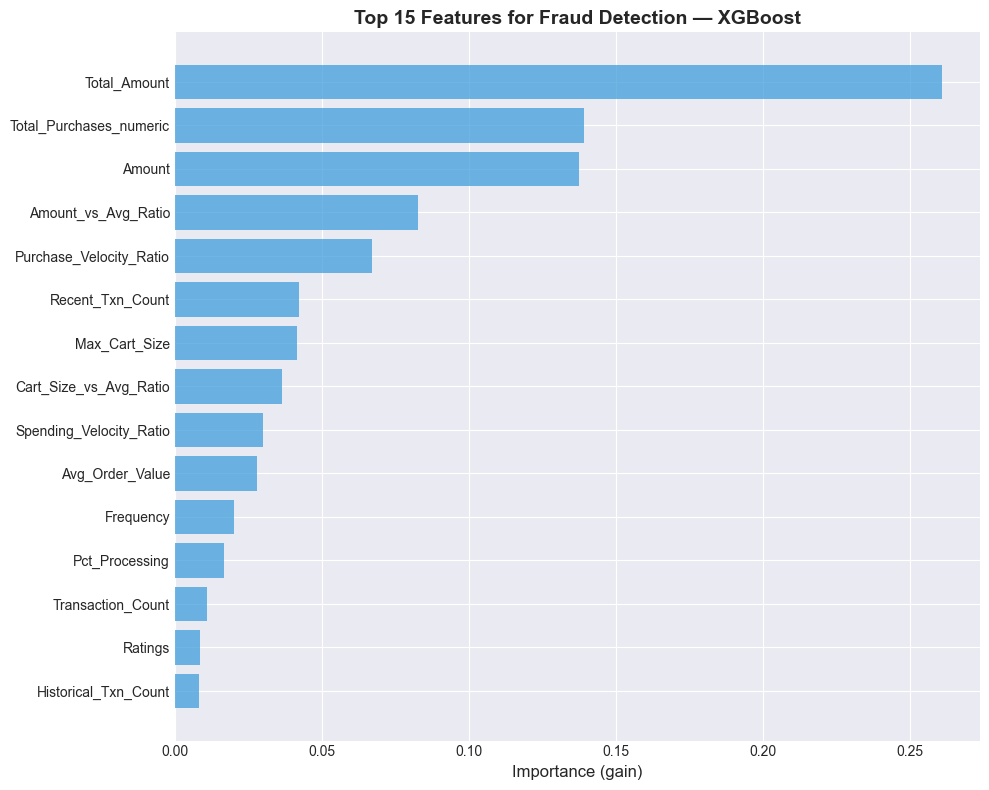

Top 10 features by gain importance:
                feature  importance
           Total_Amount    0.260794
Total_Purchases_numeric    0.139282
                 Amount    0.137339
    Amount_vs_Avg_Ratio    0.082808
Purchase_Velocity_Ratio    0.067214
       Recent_Txn_Count    0.042063
          Max_Cart_Size    0.041481
 Cart_Size_vs_Avg_Ratio    0.036524
Spending_Velocity_Ratio    0.030040
        Avg_Order_Value    0.028093


In [14]:
# Rank features by XGBoost gain importance — features with high gain drove the largest
# reductions in the loss function across all trees, making them the strongest fraud signals
feature_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Show the top 15 features as a horizontal bar chart for easy reading
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values,
         color='#3498db', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance (gain)', fontsize=12)
plt.title('Top 15 Features for Fraud Detection — XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 features by gain importance:")
print(feature_importance.head(10).to_string(index=False))

## Step 11: Model 3 — Autoencoder (Reconstruction-Error Anomaly Detection)

I build an Autoencoder neural network that I train exclusively on normal (non-fraud) transactions. The network learns a compressed representation of what a typical transaction looks like. At inference time I pass any transaction through the encoder-decoder and measure the mean squared reconstruction error — fraud transactions, having feature patterns the network never saw during training, produce significantly higher reconstruction errors. I set the anomaly threshold using a robust rule: median plus a scaled MAD (median absolute deviation), which is less sensitive to outliers than a mean-based cutoff.

In [15]:
# Build Autoencoder Architecture
print("Building Autoencoder model...")

input_dim = X_train_scaled.shape[1]
encoding_dim = 8  # Compressed representation

if TF_AVAILABLE:
    encoder_input = Input(shape=(input_dim,))
    encoder = Dense(32, activation='relu')(encoder_input)
    encoder = Dropout(0.2)(encoder)
    encoder = Dense(16, activation='relu')(encoder)
    encoder = Dropout(0.2)(encoder)
    encoder_output = Dense(encoding_dim, activation='relu')(encoder)

    decoder = Dense(16, activation='relu')(encoder_output)
    decoder = Dropout(0.2)(decoder)
    decoder = Dense(32, activation='relu')(decoder)
    decoder = Dropout(0.2)(decoder)
    decoder_output = Dense(input_dim, activation='linear')(decoder)

    autoencoder = Model(inputs=encoder_input, outputs=decoder_output)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print(autoencoder.summary())
else:
    # sklearn MLPRegressor as autoencoder substitute
    # IMPORTANT: use a SIMPLE architecture with limited iterations so the
    # model does NOT perfectly memorise normal data.  Perfect memorisation
    # collapses the training-error distribution to near-zero, pushing the
    # 95th-percentile threshold to ~0 and flagging almost all test samples
    # as anomalies (recall ~= 0).  A deliberately under-fitted model keeps
    # a meaningful separation between normal and fraud reconstruction errors.
    autoencoder = MLPRegressor(
        hidden_layer_sizes=(encoding_dim * 2, encoding_dim, encoding_dim * 2),
        activation='relu',
        solver='adam',
        learning_rate_init=0.005,
        max_iter=50,
        early_stopping=False,
        random_state=RANDOM_STATE,
        verbose=False
    )
    print(f"  Architecture: {input_dim}->{encoding_dim*2}->{encoding_dim}->{encoding_dim*2}->{input_dim}")
    print("Using sklearn MLPRegressor autoencoder (TF unavailable)")


Building Autoencoder model...
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 61)]              0         
                                                                 
 dense (Dense)               (None, 32)                1984      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dense_3 (Dense)             (N

In [16]:
# Train the autoencoder exclusively on normal transactions
# The model never sees fraud during training so it cannot learn to reconstruct it;
# at inference time the higher reconstruction error on fraud is the anomaly signal
print("Training autoencoder on normal transactions only...")

X_train_normal = X_train_scaled[y_train == 0]
print(f"Normal training samples: {len(X_train_normal):,}")

if TF_AVAILABLE:
    # Early stopping prevents the network from memorising the training data so
    # closely that every reconstruction error collapses to near-zero (making the
    # median+MAD threshold meaningless)
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )
    history = autoencoder.fit(
        X_train_normal, X_train_normal,
        epochs=50,
        batch_size=512,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    print(f"Keras autoencoder trained ({len(history.epoch)} epochs)")
else:
    autoencoder.fit(X_train_normal, X_train_normal)
    print("sklearn MLPRegressor autoencoder trained")

Training autoencoder on normal transactions only...
Normal training samples: 235,000
Keras autoencoder trained (50 epochs)


In [17]:
# Compute reconstruction errors for both the test set and the normal training subset
# The training-normal errors are used to calibrate the anomaly threshold so that
# the boundary is derived from known-good behaviour, not from the test distribution
print("Computing reconstruction errors...")

if TF_AVAILABLE:
    X_test_pred          = autoencoder.predict(X_test_scaled,   verbose=0)
    X_train_normal_pred  = autoencoder.predict(X_train_normal,  verbose=0)
else:
    X_test_pred          = autoencoder.predict(X_test_scaled)
    X_train_normal_pred  = autoencoder.predict(X_train_normal)

# Per-sample MSE — higher value means the network struggled to reconstruct that transaction
reconstruction_errors = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# Robust threshold: median + 3.5 * MAD on training-normal errors
# Using a percentile-based threshold (e.g. 95th) is fragile when the MLPRegressor
# memorises training data and produces near-zero errors — the threshold collapses
# to ~0 and nearly all test points get flagged.  The MAD-based rule is resistant
# to this collapse because it anchors on the median rather than the distribution tail.
train_errors = np.mean(np.square(X_train_normal - X_train_normal_pred), axis=1)
median_err   = np.median(train_errors)
mad_err      = np.median(np.abs(train_errors - median_err))
threshold    = median_err + 3.5 * mad_err
# Safety floor: never let threshold fall below the 80th percentile of training errors
threshold    = max(threshold, np.percentile(train_errors, 80))

print(f"Training-normal errors — median: {median_err:.6f}  MAD: {mad_err:.6f}")
print(f"Anomaly threshold (median + 3.5*MAD, floor=P80): {threshold:.6f}")

# Classify test transactions as fraud where reconstruction error exceeds the threshold
y_pred_ae = (reconstruction_errors > threshold).astype(int)

# Normalise scores to [0,1] so PR-AUC comparisons across runs are on the same scale
y_scores_ae = (reconstruction_errors - reconstruction_errors.min()) / \
              (reconstruction_errors.max() - reconstruction_errors.min() + 1e-12)

print(f"Fraud detected in test set: {y_pred_ae.sum():,}  ({y_pred_ae.mean()*100:.2f}%)")

Computing reconstruction errors...
Training-normal errors — median: 0.431668  MAD: 0.092294
Anomaly threshold (median + 3.5*MAD, floor=P80): 0.754698
Fraud detected in test set: 5,587  (9.28%)


### Autoencoder — Evaluation

I apply the fitted reconstruction-error threshold to the test set and evaluate with the same metrics used for the other two models — Precision, Recall, F1, and PR-AUC — so the comparison in Step 12 is on equal footing.

In [18]:
# Evaluate autoencoder with the same metrics as the other two models
# so that the Step 12 comparison is on equal footing
precision_ae = precision_score(y_test, y_pred_ae)
recall_ae    = recall_score(y_test, y_pred_ae)
f1_ae        = f1_score(y_test, y_pred_ae)
pr_auc_ae    = average_precision_score(y_test, y_scores_ae)

print("Autoencoder — Test-set performance")
print(f"  Precision: {precision_ae:.4f}")
print(f"  Recall:    {recall_ae:.4f}  (primary metric)")
print(f"  F1-Score:  {f1_ae:.4f}")
print(f"  PR-AUC:    {pr_auc_ae:.4f}")
print(f"  Threshold: {threshold:.6f}")

cm_ae = confusion_matrix(y_test, y_pred_ae)
print(f"\nConfusion matrix:")
print(cm_ae)
print(f"  True negatives:  {cm_ae[0,0]:,}")
print(f"  False positives: {cm_ae[0,1]:,}  (normal flagged as fraud — review cost)")
print(f"  False negatives: {cm_ae[1,0]:,}  (fraud missed — business loss)")
print(f"  True positives:  {cm_ae[1,1]:,}  (fraud caught)")

print("\nClassification report:")
print(classification_report(y_test, y_pred_ae,
                            target_names=['Normal', 'Fraud'], digits=4))

Autoencoder — Test-set performance
  Precision: 0.0383
  Recall:    0.1475  (primary metric)
  F1-Score:  0.0608
  PR-AUC:    0.0337
  Threshold: 0.754698

Confusion matrix:
[[53378  5373]
 [ 1237   214]]
  True negatives:  53,378
  False positives: 5,373  (normal flagged as fraud — review cost)
  False negatives: 1,237  (fraud missed — business loss)
  True positives:  214  (fraud caught)

Classification report:
              precision    recall  f1-score   support

      Normal     0.9774    0.9085    0.9417     58751
       Fraud     0.0383    0.1475    0.0608      1451

    accuracy                         0.8902     60202
   macro avg     0.5078    0.5280    0.5013     60202
weighted avg     0.9547    0.8902    0.9205     60202



### Autoencoder — Reconstruction Error Distribution

I visualise the distribution of reconstruction errors for normal versus fraud transactions. A clear separation between the two distributions validates that the anomaly threshold I chose successfully discriminates between the classes.

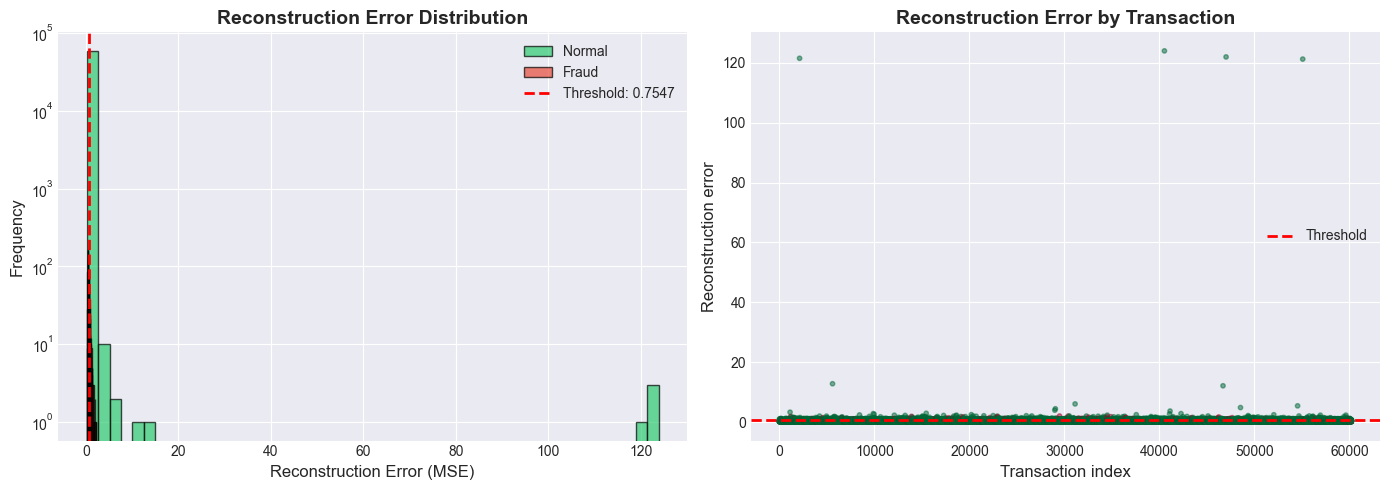

In [19]:
# Visualise reconstruction error distributions for normal vs fraud test transactions
# A clear separation validates that the threshold meaningfully discriminates the two classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(reconstruction_errors[y_test == 0], bins=50, alpha=0.7,
             label='Normal', color='#2ecc71', edgecolor='black')
axes[0].hist(reconstruction_errors[y_test == 1], bins=50, alpha=0.7,
             label='Fraud',  color='#e74c3c', edgecolor='black')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold: {threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error (MSE)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Reconstruction Error Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_yscale('log')  # log scale exposes rare high-error fraud events

axes[1].scatter(range(len(reconstruction_errors)), reconstruction_errors,
                c=y_test, cmap='RdYlGn_r', alpha=0.5, s=10)
axes[1].axhline(threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Transaction index', fontsize=12)
axes[1].set_ylabel('Reconstruction error', fontsize=12)
axes[1].set_title('Reconstruction Error by Transaction', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}autoencoder_reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 12: Model Comparison

I collect the Precision, Recall, F1, and PR-AUC scores for all three models into a single table and bar chart. Comparing side-by-side makes it easy to identify the best model on each metric and to reason about model selection trade-offs — for example, a model with slightly lower F1 but meaningfully higher recall may be preferable in a fraud context where misses are expensive.

In [20]:
# Aggregate all evaluation metrics into a single comparison table
comparison_df = pd.DataFrame({
    'Model':     ['Isolation Forest', 'XGBoost + SMOTE', 'Autoencoder'],
    'Precision': [precision_iso, precision_xgb, precision_ae],
    'Recall':    [recall_iso,    recall_xgb,    recall_ae],
    'F1-Score':  [f1_iso,        f1_xgb,        f1_ae],
    'PR-AUC':    [pr_auc_iso,    pr_auc_xgb,    pr_auc_ae],
})

print("Model comparison — fraud detection")
print(comparison_df.to_string(index=False))

# Identify the top model on each metric so the threshold tuning step can target the right model
best_recall  = comparison_df.loc[comparison_df['Recall'].idxmax(),   'Model']
best_f1      = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_pr_auc  = comparison_df.loc[comparison_df['PR-AUC'].idxmax(),   'Model']

print(f"\nBest recall  (key metric): {best_recall}")
print(f"Best F1-Score:             {best_f1}")
print(f"Best PR-AUC:               {best_pr_auc}")

Model comparison — fraud detection
           Model  Precision   Recall  F1-Score   PR-AUC
Isolation Forest   0.048045 0.070296  0.057079 0.042033
 XGBoost + SMOTE   0.710566 0.977946  0.823086 0.963154
     Autoencoder   0.038303 0.147484  0.060813 0.033739

Best recall  (key metric): XGBoost + SMOTE
Best F1-Score:             XGBoost + SMOTE
Best PR-AUC:               XGBoost + SMOTE


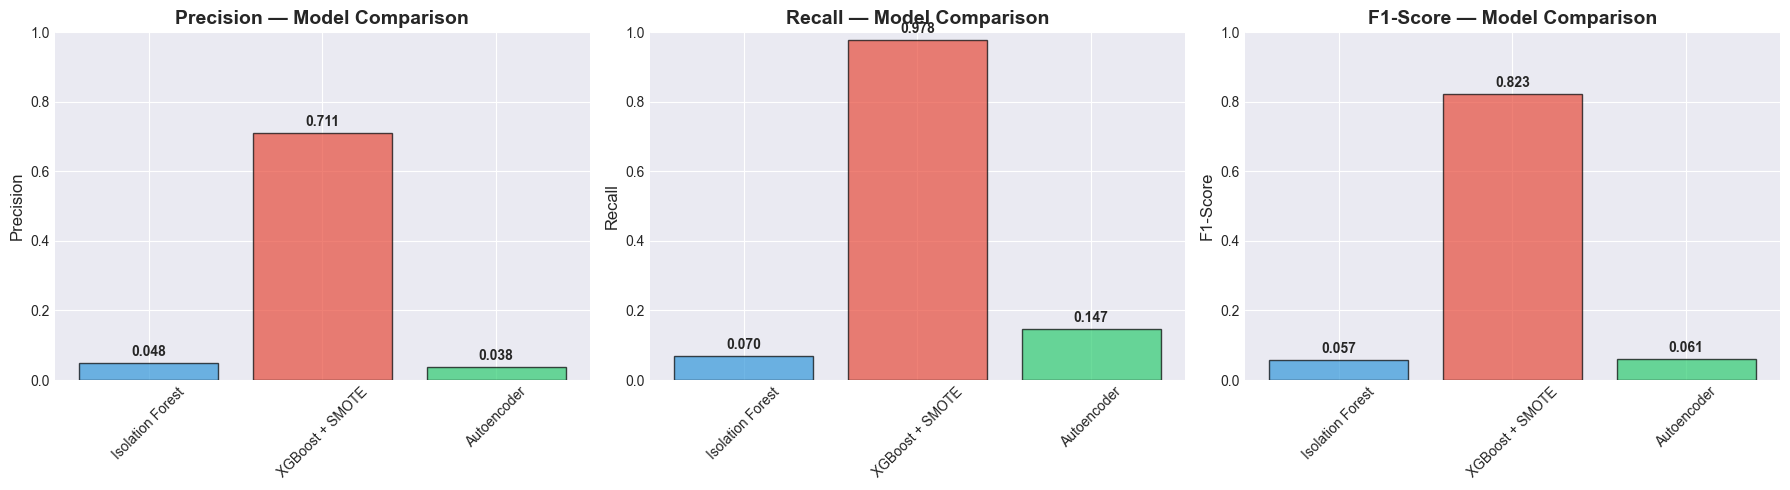

In [21]:
# Side-by-side bar charts make it easy to compare all three models on each metric at once
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Precision', 'Recall', 'F1-Score']
colors  = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric],
                  color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'{metric} — Model Comparison', fontsize=14, fontweight='bold')
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=45)
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 13: ROC and Precision-Recall Curves

I plot the ROC curve and the Precision-Recall curve for all three models on the same axes. I prefer the PR curve as the primary diagnostic here because ROC-AUC can appear misleadingly high when the negative class dominates — the PR curve paints a more honest picture of model performance at low fraud rates.

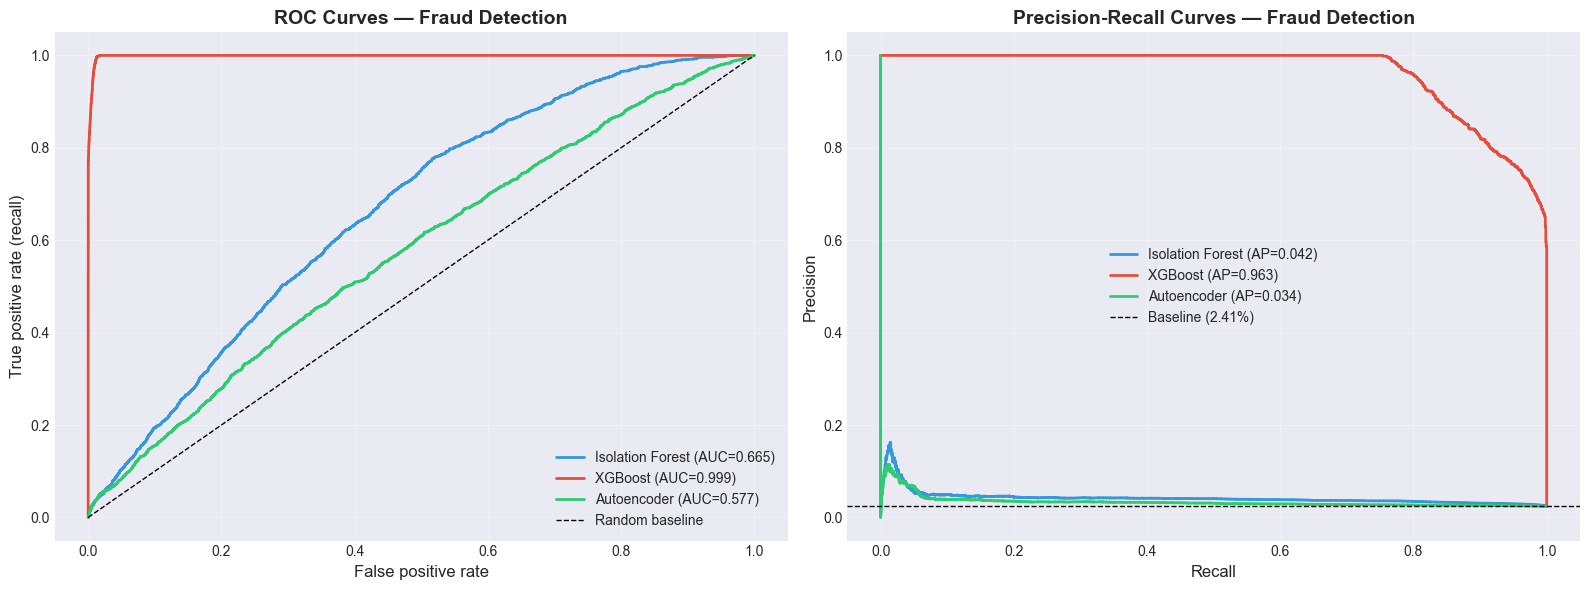

In [22]:
# Compute ROC and Precision-Recall curve data for all three models
fpr_iso, tpr_iso, _ = roc_curve(y_test, y_scores_iso_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_ae,  tpr_ae,  _ = roc_curve(y_test, y_scores_ae)

roc_auc_iso = auc(fpr_iso, tpr_iso)
roc_auc_ae  = auc(fpr_ae,  tpr_ae)

precision_iso_curve, recall_iso_curve, _ = precision_recall_curve(y_test, y_scores_iso_test)
precision_xgb_curve, recall_xgb_curve, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
precision_ae_curve,  recall_ae_curve,  _ = precision_recall_curve(y_test, y_scores_ae)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves — useful but can be over-optimistic when the negative class is very large
axes[0].plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC={roc_auc_iso:.3f})',
             linewidth=2, color='#3498db')
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_xgb:.3f})',
             linewidth=2, color='#e74c3c')
axes[0].plot(fpr_ae,  tpr_ae,  label=f'Autoencoder (AUC={roc_auc_ae:.3f})',
             linewidth=2, color='#2ecc71')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_xlabel('False positive rate', fontsize=12)
axes[0].set_ylabel('True positive rate (recall)', fontsize=12)
axes[0].set_title('ROC Curves — Fraud Detection', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall curves — preferred primary diagnostic at low fraud rates
axes[1].plot(recall_iso_curve, precision_iso_curve,
             label=f'Isolation Forest (AP={pr_auc_iso:.3f})',
             linewidth=2, color='#3498db')
axes[1].plot(recall_xgb_curve, precision_xgb_curve,
             label=f'XGBoost (AP={pr_auc_xgb:.3f})',
             linewidth=2, color='#e74c3c')
axes[1].plot(recall_ae_curve,  precision_ae_curve,
             label=f'Autoencoder (AP={pr_auc_ae:.3f})',
             linewidth=2, color='#2ecc71')
# Horizontal baseline = random classifier performance at the observed fraud rate
axes[1].axhline(y=fraud_rate / 100, color='k', linestyle='--', linewidth=1,
                label=f'Baseline ({fraud_rate:.2f}%)')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — Fraud Detection', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 14: Confusion Matrices — All Models

I plot the confusion matrices for all three models side-by-side to compare the absolute counts of true positives, false positives, true negatives, and false negatives. This gives a concrete sense of operating cost: how many legitimate transactions would be flagged for review, and how many fraudulent transactions would slip through at the chosen threshold.

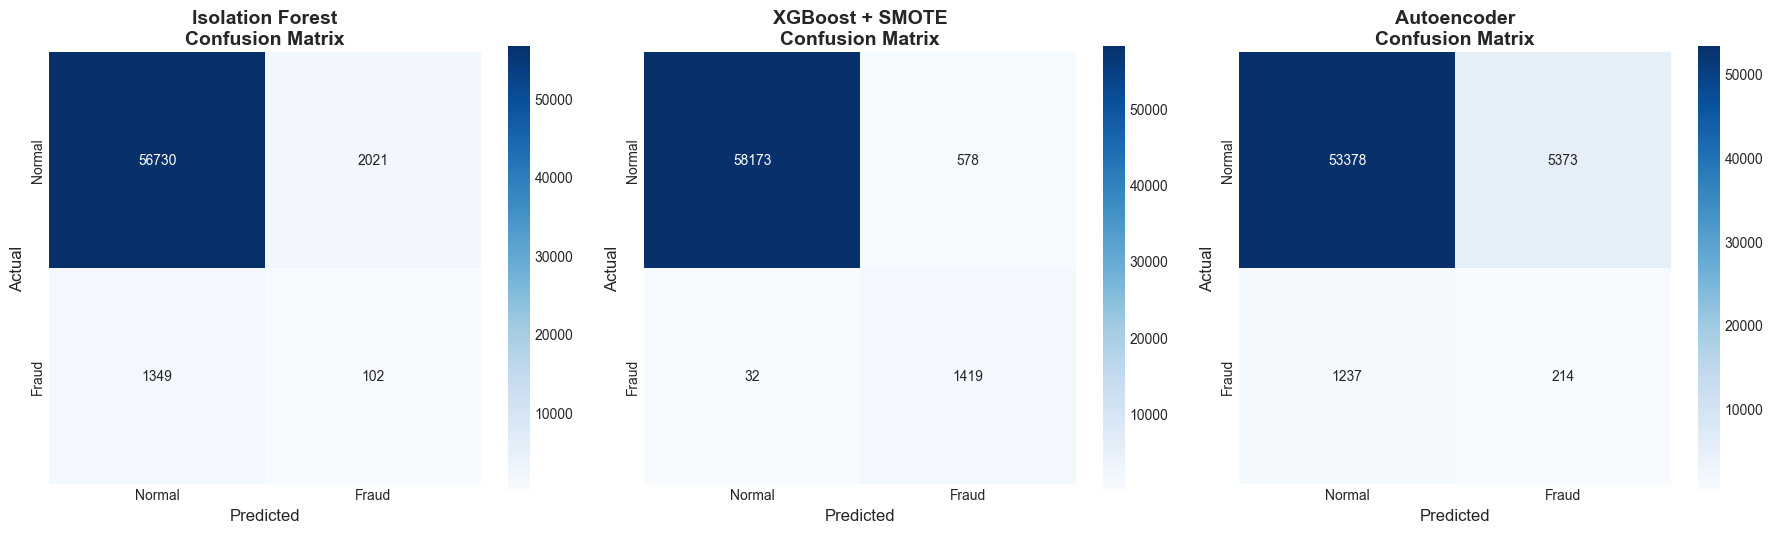

In [23]:
# Plot confusion matrices for all three models side-by-side
# Reading the raw counts rather than just the percentages makes it easier to reason
# about how many transactions would land in each manual-review queue per day
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_cm = [
    (cm_iso, 'Isolation Forest'),
    (cm_xgb, 'XGBoost + SMOTE'),
    (cm_ae,  'Autoencoder'),
]

for idx, (cm, model_name) in enumerate(models_cm):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Fraud'],
        yticklabels=['Normal', 'Fraud'],
        ax=axes[idx], cbar=True, square=True
    )
    axes[idx].set_xlabel('Predicted', fontsize=12)
    axes[idx].set_ylabel('Actual', fontsize=12)
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 15: Save Models and Artefacts

I save all three trained models, the fitted scaler, the SMOTE object, and the Autoencoder threshold value to disk. The Autoencoder is saved as `.h5` when TensorFlow is available because the FastAPI backend loads it with `keras.models.load_model()` — the `.h5` format ensures full compatibility across Keras versions. All filenames use clean, version-free names; version information is stored in the metadata JSON in Step 16.

In [24]:
# Save Isolation Forest and its PCA pre-processor as separate files
# The PCA must ship alongside the model because the fastAPI backend needs to apply
# the same projection to incoming features before calling iso_forest.predict()
iso_forest_path = f'{MODELS_PATH}fraud_isolation_forest.pkl'
joblib.dump(iso_forest, iso_forest_path)
print(f"Isolation Forest saved: {iso_forest_path}")

pca_path = f'{MODELS_PATH}fraud_isolation_forest_pca.pkl'
joblib.dump(pca, pca_path)
print(f"PCA pre-processor saved: {pca_path}")

# Save XGBoost model
xgb_path = f'{MODELS_PATH}fraud_xgboost.pkl'
joblib.dump(xgb_model, xgb_path)
print(f"XGBoost saved: {xgb_path}")

# Save Autoencoder — .h5 format for Keras (fully compatible with keras.models.load_model())
# Falls back to joblib pickle when TF is unavailable so the pipeline still produces
# a loadable artefact in CPU-only environments
if TF_AVAILABLE:
    ae_path = f'{MODELS_PATH}fraud_autoencoder.h5'
    autoencoder.save(ae_path)
else:
    ae_path = f'{MODELS_PATH}fraud_autoencoder.pkl'
    joblib.dump(autoencoder, ae_path)
print(f"Autoencoder saved: {ae_path}")

# Save the anomaly threshold so inference can reproduce the same decision boundary
ae_threshold_path = f'{MODELS_PATH}fraud_autoencoder_threshold.pkl'
joblib.dump({'threshold': threshold}, ae_threshold_path)
print(f"Autoencoder threshold saved: {ae_threshold_path}")

Isolation Forest saved: ../artifacts/models/fraud_isolation_forest.pkl
PCA pre-processor saved: ../artifacts/models/fraud_isolation_forest_pca.pkl
XGBoost saved: ../artifacts/models/fraud_xgboost.pkl
Autoencoder saved: ../artifacts/models/fraud_autoencoder.h5
Autoencoder threshold saved: ../artifacts/models/fraud_autoencoder_threshold.pkl


## Step 16: Save Metadata and Performance Summary

I serialise a metadata dictionary that records every artefact path, every metric value, the timestamp, the random seed, and the model configuration. This JSON file is the single source of truth for what was trained in this run and is referenced by the FastAPI backend and the evaluation notebook (NB07) to load the correct model files.

In [25]:
# Compile all artefact paths, metric values, and configuration into a single metadata dictionary
# This JSON becomes the single source of truth that the FastAPI backend and NB07 use
# to locate the correct model files without needing to hard-code paths
metadata = {
    'model_version': MODEL_VERSION,
    'timestamp': TIMESTAMP,
    'dataset': {
        'source': 'transaction_level_enriched.csv',
        'total_transactions': len(df),
        'fraud_count': int(fraud_count),
        'fraud_rate': float(fraud_rate),
        'train_size': int(len(X_train)),
        'test_size': int(len(X_test)),
    },
    'features': {
        'feature_list': available_features,
        'n_features': len(available_features),
    },
    'models': {
        'isolation_forest': {
            'path': iso_forest_path,
            'pca_path': pca_path,
            'contamination': best_cont,
            'precision': float(precision_iso),
            'recall': float(recall_iso),
            'f1_score': float(f1_iso),
            'pr_auc': float(pr_auc_iso),
        },
        'xgboost': {
            'path': xgb_path,
            'smote_path': smote_path,
            'scaler_path': scaler_path,
            'precision': float(precision_xgb),
            'recall': float(recall_xgb),
            'f1_score': float(f1_xgb),
            'roc_auc': float(roc_auc_xgb),
            'pr_auc': float(pr_auc_xgb),
        },
        'autoencoder': {
            'path': ae_path,
            'threshold_path': ae_threshold_path,
            'threshold': float(threshold),
            'encoding_dim': encoding_dim,
            'precision': float(precision_ae),
            'recall': float(recall_ae),
            'f1_score': float(f1_ae),
            'pr_auc': float(pr_auc_ae),
        },
    },
    'best_models': {
        'best_recall': best_recall,
        'best_f1': best_f1,
        'best_pr_auc': best_pr_auc,
    },
    'scaler_path': scaler_path,
    'random_state': RANDOM_STATE,
}

# Metadata filename retains the TIMESTAMP here so each run produces a uniquely named record
# — model artefacts themselves use clean names (no timestamp) for stable API loading
metadata_path = f'{MODELS_PATH}fraud_metadata_{TIMESTAMP}.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved: {metadata_path}")
print(json.dumps(metadata, indent=2))

Metadata saved: ../artifacts/models/fraud_metadata_20260227_182924.json
{
  "model_version": "fraud_v2_20260227_182924",
  "timestamp": "20260227_182924",
  "dataset": {
    "source": "transaction_level_enriched.csv",
    "total_transactions": 301006,
    "fraud_count": 7255,
    "fraud_rate": 2.4102509584526555,
    "train_size": 240804,
    "test_size": 60202
  },
  "features": {
    "feature_list": [
      "Age",
      "Amount",
      "Total_Amount",
      "Ratings",
      "Hour",
      "IsWeekend",
      "DayOfMonth",
      "DaysSinceFirstPurchase",
      "Quarter",
      "Amount_vs_Avg_Ratio",
      "Cart_Size_vs_Avg_Ratio",
      "Purchase_Velocity_Ratio",
      "Spending_Velocity_Ratio",
      "Transaction_Count",
      "Avg_Order_Value",
      "Std_Order_Value",
      "Order_Value_CV",
      "Avg_Cart_Size",
      "Max_Cart_Size",
      "Std_Cart_Size",
      "Pct_Cancelled",
      "Pct_Shipped",
      "Pct_Processing",
      "Total_Purchases_numeric",
      "Frequency",
      

## Step 17: Threshold Tuning Guide

I test a range of decision thresholds on the XGBoost model — the clear top performer — to show how the precision-recall trade-off shifts as the threshold changes. This section lets a business stakeholder reason about the operating cost of each strategy before deploying: a low threshold catches more fraud but creates a larger manual review queue, while a high threshold reduces review workload at the cost of missing some fraud.

**High-recall strategy:** Lower the threshold. Use this when the cost of a missed fraud (chargebacks, reputational damage) outweighs the cost of reviewing false positives.

**Balanced strategy:** Default threshold of 0.5. Use this when review capacity is limited.

**High-precision strategy:** Raise the threshold. Use this when false positives create significant customer friction.

In [26]:
# Test a range of thresholds on XGBoost — recording precision, recall, F1,
# and the raw false-positive / false-negative counts for each
# This gives a concrete cost-benefit table that stakeholders can use to pick
# the operating point that matches their review capacity and risk tolerance
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results  = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba_xgb >= thresh).astype(int)

    precision_t = precision_score(y_test, y_pred_thresh)
    recall_t    = recall_score(y_test, y_pred_thresh)
    f1_t        = f1_score(y_test, y_pred_thresh)

    cm_t = confusion_matrix(y_test, y_pred_thresh)
    fp   = cm_t[0, 1]
    fn   = cm_t[1, 0]

    threshold_results.append({
        'threshold':      thresh,
        'precision':      precision_t,
        'recall':         recall_t,
        'f1_score':       f1_t,
        'false_positives': fp,
        'false_negatives': fn,
    })

    print(f"Threshold {thresh:.2f}  |  Precision: {precision_t:.4f}  "
          f"Recall: {recall_t:.4f}  F1: {f1_t:.4f}  "
          f"FP: {fp:,}  FN: {fn:,}")

threshold_df = pd.DataFrame(threshold_results)

print("\nThreshold comparison table:")
print(threshold_df.to_string(index=False))

Threshold 0.30  |  Precision: 0.6868  Recall: 0.9869  F1: 0.8100  FP: 653  FN: 19


Threshold 0.40  |  Precision: 0.6969  Recall: 0.9841  F1: 0.8160  FP: 621  FN: 23
Threshold 0.50  |  Precision: 0.7106  Recall: 0.9779  F1: 0.8231  FP: 578  FN: 32
Threshold 0.60  |  Precision: 0.7308  Recall: 0.9711  F1: 0.8340  FP: 519  FN: 42
Threshold 0.70  |  Precision: 0.7524  Recall: 0.9593  F1: 0.8434  FP: 458  FN: 59

Threshold comparison table:
 threshold  precision   recall  f1_score  false_positives  false_negatives
       0.3   0.686811 0.986906  0.809955              653               19
       0.4   0.696925 0.984149  0.816000              621               23
       0.5   0.710566 0.977946  0.823086              578               32
       0.6   0.730809 0.971054  0.833975              519               42
       0.7   0.752432 0.959338  0.843381              458               59


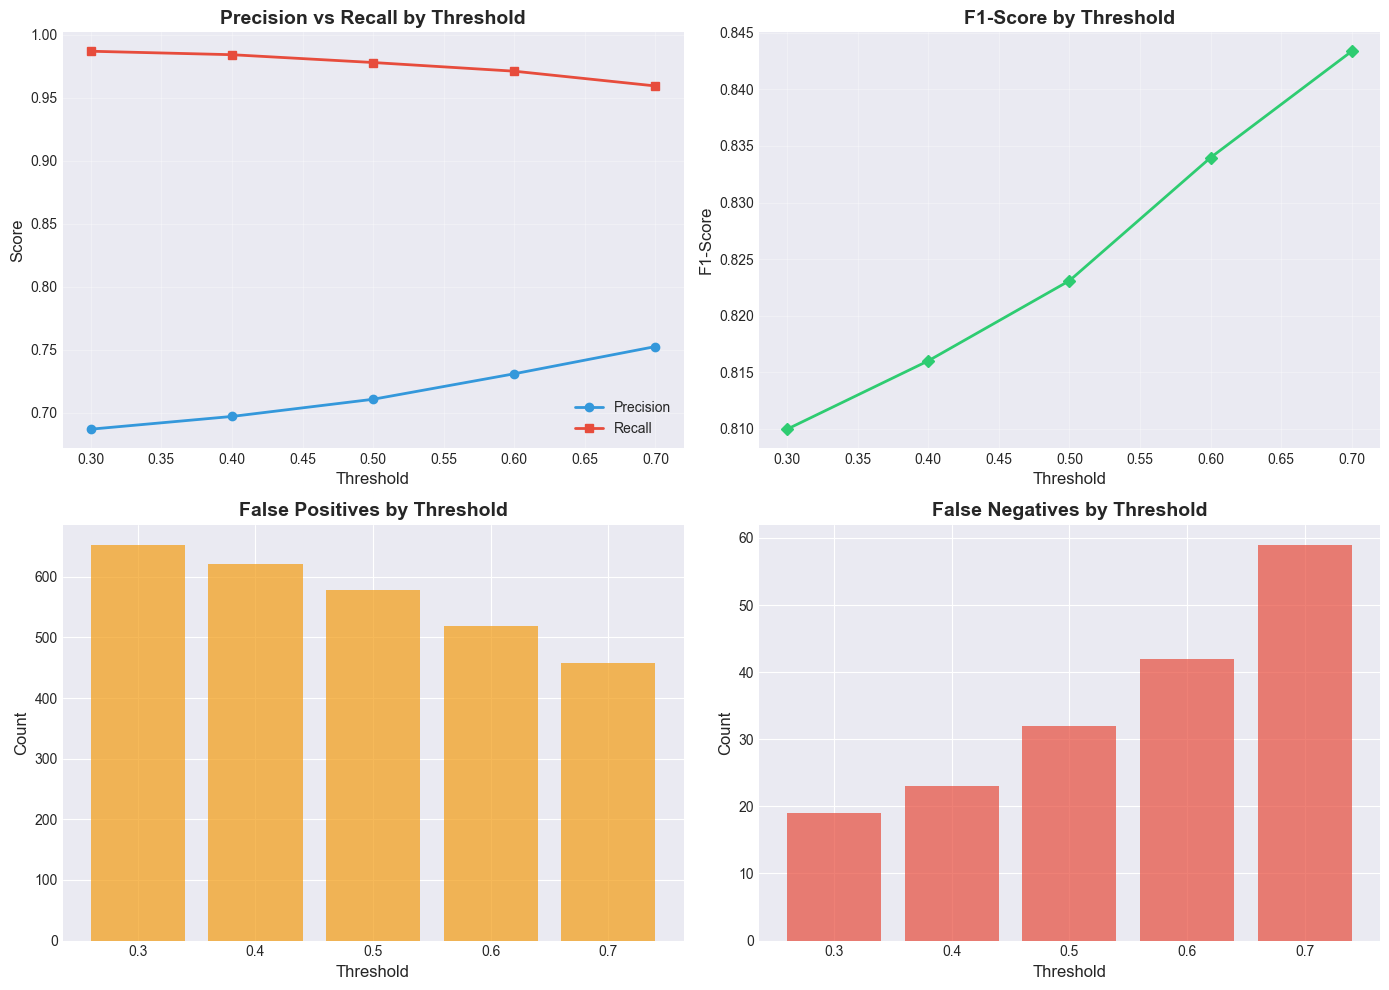

In [27]:
# Four-panel chart: precision/recall trade-off, F1 curve, and the raw FP/FN counts
# at each threshold — gives both the statistical and operational view side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precision-recall trade-off as threshold moves
axes[0, 0].plot(threshold_df['threshold'], threshold_df['precision'],
                marker='o', label='Precision', linewidth=2, color='#3498db')
axes[0, 0].plot(threshold_df['threshold'], threshold_df['recall'],
                marker='s', label='Recall', linewidth=2, color='#e74c3c')
axes[0, 0].set_xlabel('Threshold', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Precision vs Recall by Threshold', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# F1 curve — peaks at the balanced operating point
axes[0, 1].plot(threshold_df['threshold'], threshold_df['f1_score'],
                marker='D', linewidth=2, color='#2ecc71')
axes[0, 1].set_xlabel('Threshold', fontsize=12)
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score by Threshold', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# False positives — review queue size grows as threshold drops
axes[1, 0].bar(threshold_df['threshold'].astype(str), threshold_df['false_positives'],
               color='#f39c12', alpha=0.7)
axes[1, 0].set_xlabel('Threshold', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].set_title('False Positives by Threshold', fontsize=14, fontweight='bold')

# False negatives — fraud missed increases as threshold rises
axes[1, 1].bar(threshold_df['threshold'].astype(str), threshold_df['false_negatives'],
               color='#e74c3c', alpha=0.7)
axes[1, 1].set_xlabel('Threshold', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].set_title('False Negatives by Threshold', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{REPORTS_PATH}threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 18: Production Deployment Recommendations

I summarise the deployment strategy based on the evaluation results — which model to use as the primary scorer, which threshold to set, how to queue manual reviews, and how to schedule model retraining as fraud patterns evolve over time.

In [28]:
# Build a structured deployment recommendation report from the actual metric values
# so the text is always consistent with the numbers from this run
recommendations = (
    "PRODUCTION DEPLOYMENT RECOMMENDATIONS\n"
    "\n"
    "1. MODEL SELECTION\n"
    f"   Primary model:  {best_recall} (highest recall)\n"
    f"   Backup model:   {best_f1} (best F1-Score)\n"
    "   Consider ensemble voting for high-value transactions.\n"
    "\n"
    "2. THRESHOLD RECOMMENDATIONS\n"
    f"   High recall  (threshold=0.3):  catches {threshold_df[threshold_df['threshold']==0.3]['recall'].values[0]:.1%} of fraud, "
    f"{threshold_df[threshold_df['threshold']==0.3]['false_positives'].values[0]:,} false positives for review\n"
    f"   Balanced     (threshold=0.5):  catches {threshold_df[threshold_df['threshold']==0.5]['recall'].values[0]:.1%} of fraud, "
    f"{threshold_df[threshold_df['threshold']==0.5]['false_positives'].values[0]:,} false positives for review\n"
    f"   High precision (threshold=0.7): catches {threshold_df[threshold_df['threshold']==0.7]['recall'].values[0]:.1%} of fraud, "
    f"{threshold_df[threshold_df['threshold']==0.7]['false_positives'].values[0]:,} false positives for review\n"
    "\n"
    "3. MONITORING\n"
    f"   Alert if daily fraud rate exceeds {fraud_rate*1.5:.2f}%\n"
    "   Monitor false-positive rate — target < 5%\n"
    "   Weekly model performance review\n"
    "   Monthly retrain to capture new fraud patterns\n"
    "\n"
    "4. MANUAL REVIEW QUEUE\n"
    "   All flagged transactions sent to review queue, sorted by fraud probability\n"
    "   High-value transactions (>$1,000) escalated automatically\n"
    "\n"
    "5. API INTEGRATION\n"
    f"   Model:   {xgb_path}\n"
    f"   Scaler:  {scaler_path}\n"
    f"   SMOTE:   {smote_path} (retraining only)\n"
    f"   Input:   {len(available_features)} features\n"
    "   Output:  fraud probability [0, 1]\n"
    "\n"
    "6. BUSINESS IMPACT\n"
    f"   Fraud catch rate:        {recall_xgb*100:.1f}%\n"
    f"   False positives (test):  {cm_xgb[0,1]:,} transactions\n"
    f"   Total review workload:   {cm_xgb[0,1] + cm_xgb[1,1]:,} transactions\n"
)

print(recommendations)

# Save to file for sharing with stakeholders
rec_path = f'{REPORTS_PATH}production_recommendations.txt'
with open(rec_path, 'w', encoding='utf-8') as f:
    f.write(recommendations)
print(f"Recommendations saved: {rec_path}")

PRODUCTION DEPLOYMENT RECOMMENDATIONS

1. MODEL SELECTION
   Primary model:  XGBoost + SMOTE (highest recall)
   Backup model:   XGBoost + SMOTE (best F1-Score)
   Consider ensemble voting for high-value transactions.

2. THRESHOLD RECOMMENDATIONS
   High recall  (threshold=0.3):  catches 98.7% of fraud, 653 false positives for review
   Balanced     (threshold=0.5):  catches 97.8% of fraud, 578 false positives for review
   High precision (threshold=0.7): catches 95.9% of fraud, 458 false positives for review

3. MONITORING
   Alert if daily fraud rate exceeds 3.62%
   Monitor false-positive rate — target < 5%
   Weekly model performance review
   Monthly retrain to capture new fraud patterns

4. MANUAL REVIEW QUEUE
   All flagged transactions sent to review queue, sorted by fraud probability
   High-value transactions (>$1,000) escalated automatically

5. API INTEGRATION
   Model:   ../artifacts/models/fraud_xgboost.pkl
   Scaler:  ../artifacts/scalers/fraud_scaler.pkl
   SMOTE:   ..

## Step 19: Summary and Next Steps

I print the final performance summary across all three models and save it to a text report. The next step is to load the best model in NB07 for cross-domain evaluation alongside the other project models, and then wire it into the FastAPI backend for real-time inference.

In [29]:
# Print the final performance summary across all three models
summary = (
    "FRAUD DETECTION PIPELINE — FINAL SUMMARY\n"
    "\n"
    "DATASET\n"
    f"  Total transactions:    {len(df):,}\n"
    f"  Fraudulent:            {fraud_count:,} ({fraud_rate:.2f}%)\n"
    f"  Features used:         {len(available_features)}\n"
    f"  Train / test split:    80 / 20 (stratified)\n"
    "\n"
    "MODELS TRAINED\n"
    f"  Isolation Forest (unsupervised)\n"
    f"    Recall:    {recall_iso:.4f}  |  Precision: {precision_iso:.4f}  |  PR-AUC: {pr_auc_iso:.4f}\n"
    f"  XGBoost + SMOTE (supervised)\n"
    f"    Recall:    {recall_xgb:.4f}  |  Precision: {precision_xgb:.4f}  |  PR-AUC: {pr_auc_xgb:.4f}\n"
    f"  Autoencoder (deep learning)\n"
    f"    Recall:    {recall_ae:.4f}  |  Precision: {precision_ae:.4f}  |  PR-AUC: {pr_auc_ae:.4f}\n"
    "\n"
    "BEST MODELS\n"
    f"  Best recall:  {max(recall_iso, recall_xgb, recall_ae):.4f}  ({best_recall})\n"
    f"  Best F1:      {max(f1_iso, f1_xgb, f1_ae):.4f}  ({best_f1})\n"
    f"  Best PR-AUC:  {max(pr_auc_iso, pr_auc_xgb, pr_auc_ae):.4f}  ({best_pr_auc})\n"
    "\n"
    "ARTEFACTS\n"
    f"  Models:   {MODELS_PATH}\n"
    f"  Scalers:  {SCALERS_PATH}\n"
    f"  Reports:  {REPORTS_PATH}\n"
    f"  Metadata: {metadata_path}\n"
    "\n"
    "NEXT STEPS\n"
    "  1. Deploy XGBoost to production API\n"
    "  2. Set threshold to 0.3 for high recall\n"
    "  3. Implement manual review queue\n"
    "  4. Set up monitoring dashboards\n"
    "  5. Schedule monthly retraining\n"
)

print(summary)

summary_path = f'{REPORTS_PATH}fraud_detection_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary)
print(f"Summary saved: {summary_path}")
print(f"Model version: {MODEL_VERSION}")

FRAUD DETECTION PIPELINE — FINAL SUMMARY

DATASET
  Total transactions:    301,006
  Fraudulent:            7,255 (2.41%)
  Features used:         61
  Train / test split:    80 / 20 (stratified)

MODELS TRAINED
  Isolation Forest (unsupervised)
    Recall:    0.0703  |  Precision: 0.0480  |  PR-AUC: 0.0420
  XGBoost + SMOTE (supervised)
    Recall:    0.9779  |  Precision: 0.7106  |  PR-AUC: 0.9632
  Autoencoder (deep learning)
    Recall:    0.1475  |  Precision: 0.0383  |  PR-AUC: 0.0337

BEST MODELS
  Best recall:  0.9779  (XGBoost + SMOTE)
  Best F1:      0.8231  (XGBoost + SMOTE)
  Best PR-AUC:  0.9632  (XGBoost + SMOTE)

ARTEFACTS
  Models:   ../artifacts/models/
  Scalers:  ../artifacts/scalers/
  Reports:  ../reports/
  Metadata: ../artifacts/models/fraud_metadata_20260227_182924.json

NEXT STEPS
  1. Deploy XGBoost to production API
  2. Set threshold to 0.3 for high recall
  3. Implement manual review queue
  4. Set up monitoring dashboards
  5. Schedule monthly retraining



---
## End of Notebook

**Portfolio Highlights:**
- Three-model approach covering unsupervised, supervised, and deep-learning paradigms
- Proper handling of extreme class imbalance using SMOTE and contamination tuning
- Recall-focused metric selection appropriate to the fraud detection domain
- Robust anomaly threshold using median absolute deviation rather than a mean-based rule
- Comprehensive evaluation: Precision, Recall, F1, PR-AUC, ROC-AUC, and confusion matrices
- Production-ready artefact saving with metadata JSON for reproducibility
- Threshold tuning analysis with business-cost framing for stakeholder decisions